In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [2]:
DATA_DIR = Path(
    "../data/casting_512x512"
)

MODEL_PATH = Path(
    "../models/final_mobilenetv2_finetuned.keras"
)

IMAGE_SIZE = (224, 224)
SEED = 42

In [3]:
print("Dataset exists:", DATA_DIR.exists())
print("Model exists:", MODEL_PATH.exists())

Dataset exists: True
Model exists: True


In [4]:
model = tf.keras.models.load_model(
    MODEL_PATH
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,183,365 (23.59 MB)

 Trainable params: 1,921,665 (7.33 MB)

 Non-trainable params: 418,368 (1.60 MB)

 Optimizer params: 3,843,332 (14.66 MB)

In [5]:
ok_images = [
    p for p in (DATA_DIR / "ok_front").iterdir()
    if p.is_file()
]

defective_images = [
    p for p in (DATA_DIR / "def_front").iterdir()
    if p.is_file()
]

image_paths = np.array(
    [str(p) for p in ok_images + defective_images]
)

labels = np.array(
    [0] * len(ok_images) +
    [1] * len(defective_images)
)

In [6]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

In [7]:
defective_test_paths = [
    path for path, label in zip(test_paths, test_labels)
    if label == 1
]

print(
    "Defective test images:",
    len(defective_test_paths)
)

print(
    defective_test_paths[:5]
)

Defective test images: 117
[np.str_('..\\data\\casting_512x512\\def_front\\cast_def_0_5034.jpeg'), np.str_('..\\data\\casting_512x512\\def_front\\cast_def_0_3334.jpeg'), np.str_('..\\data\\casting_512x512\\def_front\\cast_def_0_3220.jpeg'), np.str_('..\\data\\casting_512x512\\def_front\\cast_def_0_7431.jpeg'), np.str_('..\\data\\casting_512x512\\def_front\\cast_def_0_3565.jpeg')]


In [8]:
def load_image(image_path):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image

In [9]:
image_path = defective_test_paths[0]

image = load_image(image_path)

input_tensor = tf.expand_dims(
    image,
    axis=0
)

prediction = model.predict(
    input_tensor,
    verbose=0
)[0][0]

print("Prediction probability:", prediction)

Prediction probability: 0.9999998


In [10]:
for layer in reversed(model.layers):
    if isinstance(layer, layers.Conv2D):
        print("Last Conv2D layer:", layer.name)
        break

In [14]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer).__name__)

0 input_layer_1 InputLayer
1 mobilenetv2_1.00_224 Functional
2 global_average_pooling2d GlobalAveragePooling2D
3 dropout Dropout
4 dense Dense
5 dropout_1 Dropout
6 dense_1 Dense


In [15]:
base_model = model.get_layer("mobilenetv2_1.00_224")

print("Base model:", base_model.name)
print("Number of layers:", len(base_model.layers))

Base model: mobilenetv2_1.00_224
Number of layers: 154


In [16]:
for i, layer in enumerate(base_model.layers[-10:]):
    print(
        len(base_model.layers) - 10 + i,
        layer.name,
        type(layer).__name__
    )

144 block_16_expand_BN BatchNormalization
145 block_16_expand_relu ReLU
146 block_16_depthwise DepthwiseConv2D
147 block_16_depthwise_BN BatchNormalization
148 block_16_depthwise_relu ReLU
149 block_16_project Conv2D
150 block_16_project_BN BatchNormalization
151 Conv_1 Conv2D
152 Conv_1_bn BatchNormalization
153 out_relu ReLU


In [17]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer).__name__)

0 input_layer_1 InputLayer
1 mobilenetv2_1.00_224 Functional
2 global_average_pooling2d GlobalAveragePooling2D
3 dropout Dropout
4 dense Dense
5 dropout_1 Dropout
6 dense_1 Dense


In [18]:
# Find the nested MobileNetV2 model
base_model = None

for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        print("Found base model:", layer.name)
        break

if base_model is None:
    print("No nested model found.")
else:
    print("Number of layers:", len(base_model.layers))

Found base model: mobilenetv2_1.00_224
Number of layers: 154


In [19]:
# Inspect the last 15 layers
for i, layer in enumerate(base_model.layers[-15:]):
    print(
        len(base_model.layers) - 15 + i,
        layer.name,
        type(layer).__name__
    )

139 block_15_depthwise_relu ReLU
140 block_15_project Conv2D
141 block_15_project_BN BatchNormalization
142 block_15_add Add
143 block_16_expand Conv2D
144 block_16_expand_BN BatchNormalization
145 block_16_expand_relu ReLU
146 block_16_depthwise DepthwiseConv2D
147 block_16_depthwise_BN BatchNormalization
148 block_16_depthwise_relu ReLU
149 block_16_project Conv2D
150 block_16_project_BN BatchNormalization
151 Conv_1 Conv2D
152 Conv_1_bn BatchNormalization
153 out_relu ReLU


In [20]:
# Find the last convolutional layer inside MobileNetV2

conv_layers = []

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        conv_layers.append(layer)

print("Number of Conv2D layers:", len(conv_layers))

if conv_layers:
    last_conv_layer = conv_layers[-1]
    print("Last Conv2D layer:", last_conv_layer.name)
else:
    print("No Conv2D layer found.")

Number of Conv2D layers: 35
Last Conv2D layer: Conv_1


In [21]:
def make_gradcam_heatmap(img_array, model, last_conv_layer):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            last_conv_layer.output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        # Binary classification: use the model's output
        class_score = predictions[:, 0]

    # Gradient of prediction with respect to feature maps
    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    # Average gradients across spatial dimensions
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight feature maps by their importance
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU: keep positive contributions
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize 0 → 1
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap /= max_value

    return heatmap.numpy()

In [22]:
image_path = defective_test_paths[0]

In [23]:
image = load_image(image_path)

input_tensor = tf.expand_dims(
    image,
    axis=0
)

In [24]:
prediction = model.predict(
    input_tensor,
    verbose=0
)[0][0]

print("Image:", image_path)
print("Defective probability:", prediction)

Image: ..\data\casting_512x512\def_front\cast_def_0_5034.jpeg
Defective probability: 0.9999998


In [27]:
for layer in model.layers:
    print(layer.name, type(layer).__name__)

input_layer_1 InputLayer
mobilenetv2_1.00_224 Functional
global_average_pooling2d GlobalAveragePooling2D
dropout Dropout
dense Dense
dropout_1 Dropout
dense_1 Dense


In [28]:
base_model = None

for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

print("Base model:", base_model.name)

Base model: mobilenetv2_1.00_224


In [29]:
conv_layers = [
    layer
    for layer in base_model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

last_conv_layer = conv_layers[-1]

print("Last convolutional layer:")
print(last_conv_layer.name)
print("Output shape:", last_conv_layer.output.shape)

Last convolutional layer:
Conv_1
Output shape: (None, 7, 7, 1280)


In [30]:
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        last_conv_layer.output,
        base_model.output
    ]
)

In [31]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

base_model = None

for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

print("Base model:", base_model.name)

Base model: mobilenetv2_1.00_224


In [32]:
conv_layers = [
    layer
    for layer in base_model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

last_conv_layer = conv_layers[-1]

print("Last Conv2D:", last_conv_layer.name)
print("Output shape:", last_conv_layer.output.shape)

Last Conv2D: Conv_1
Output shape: (None, 7, 7, 1280)


In [33]:
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        last_conv_layer.output,
        base_model.output
    ]
)

print("Grad-CAM model created successfully.")

Grad-CAM model created successfully.


In [34]:
def make_gradcam_heatmap(
    image_tensor,
    base_model,
    last_conv_layer
):
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            last_conv_layer.output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, feature_output = grad_model(
            image_tensor,
            training=False
        )

        # Global average pooling
        pooled = tf.reduce_mean(
            feature_output,
            axis=[1, 2]
        )

        # Gradient of the feature representation
        grads = tape.gradient(
            pooled,
            conv_outputs
        )

    weights = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    weights = weights[0]

    heatmap = tf.reduce_sum(
        conv_outputs * weights,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap = heatmap / (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()

In [35]:
print("Outer model input:", model.input.shape)
print("Outer model output:", model.output.shape)
print("Base model input:", base_model.input.shape)
print("Base model output:", base_model.output.shape)

Outer model input: (None, 224, 224, 3)
Outer model output: (None, 1)
Base model input: (None, 224, 224, 3)
Base model output: (None, 7, 7, 1280)


In [36]:
print("Base model name:", base_model.name)
print("Last convolution:", last_conv_layer.name)
print("Last convolution output:", last_conv_layer.output.shape)

Base model name: mobilenetv2_1.00_224
Last convolution: Conv_1
Last convolution output: (None, 7, 7, 1280)


In [37]:
# Find the MobileNetV2 base model
base_model = None

for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

print("Base model:", base_model.name)

Base model: mobilenetv2_1.00_224


In [38]:
candidate_layers = []

for layer in base_model.layers:
    try:
        shape = layer.output.shape
        if len(shape) == 4:
            candidate_layers.append(layer)
    except:
        pass

for layer in candidate_layers[-10:]:
    print(layer.name, layer.output.shape)

block_16_expand_BN (None, 7, 7, 960)
block_16_expand_relu (None, 7, 7, 960)
block_16_depthwise (None, 7, 7, 960)
block_16_depthwise_BN (None, 7, 7, 960)
block_16_depthwise_relu (None, 7, 7, 960)
block_16_project (None, 7, 7, 320)
block_16_project_BN (None, 7, 7, 320)
Conv_1 (None, 7, 7, 1280)
Conv_1_bn (None, 7, 7, 1280)
out_relu (None, 7, 7, 1280)


In [39]:
last_conv_layer = candidate_layers[-1]

print("Selected Grad-CAM layer:", last_conv_layer.name)
print("Shape:", last_conv_layer.output.shape)

Selected Grad-CAM layer: out_relu
Shape: (None, 7, 7, 1280)


In [40]:
def make_gradcam_heatmap(image_tensor, model, base_model, last_conv_layer):

    # Model that gives us the convolutional feature maps
    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=last_conv_layer.output
    )

    with tf.GradientTape() as tape:

        # Get feature maps
        conv_outputs = conv_model(
            image_tensor,
            training=False
        )

        # Continue through the rest of the original model
        x = conv_outputs

        # Find where the selected layer sits and use the
        # remaining layers of MobileNetV2
        layer_index = base_model.layers.index(last_conv_layer)

        for layer in base_model.layers[layer_index + 1:]:
            x = layer(x, training=False)

        # Now x is MobileNetV2's feature output
        x = model.layers[2](x)

        x = model.layers[3](x, training=False)
        x = model.layers[4](x, training=False)
        x = model.layers[5](x, training=False)
        predictions = model.layers[6](x, training=False)

        class_score = predictions[:, 0]

    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()

In [41]:
heatmap = make_gradcam_heatmap(
    input_tensor,
    model,
    base_model,
    last_conv_layer
)

print("Heatmap shape:", heatmap.shape)
print("Min:", heatmap.min())
print("Max:", heatmap.max())

Heatmap shape: (7, 7)
Min: 0.0067953034
Max: 0.98229975


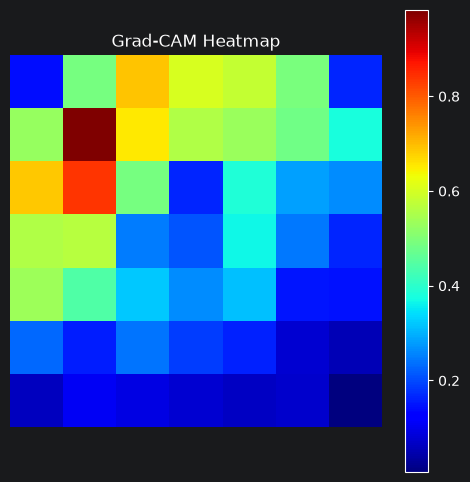

In [42]:
plt.figure(figsize=(6, 6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.show()

In [45]:
import numpy as np
import matplotlib.pyplot as plt

heatmap_uint8 = np.uint8(255 * heatmap)

# New Matplotlib API
jet = plt.colormaps["jet"]

jet_colors = jet(
    np.arange(256)
)[:, :3]

jet_heatmap = jet_colors[heatmap_uint8]

jet_heatmap = tf.keras.utils.array_to_img(
    jet_heatmap
)

jet_heatmap = jet_heatmap.resize(
    (IMAGE_SIZE[1], IMAGE_SIZE[0])
)

jet_heatmap = tf.keras.utils.img_to_array(
    jet_heatmap
)

In [46]:
original_image = image.numpy()

superimposed = (
    original_image * 0.6 +
    jet_heatmap * 0.4
)

superimposed = np.clip(
    superimposed,
    0,
    255
).astype("uint8")

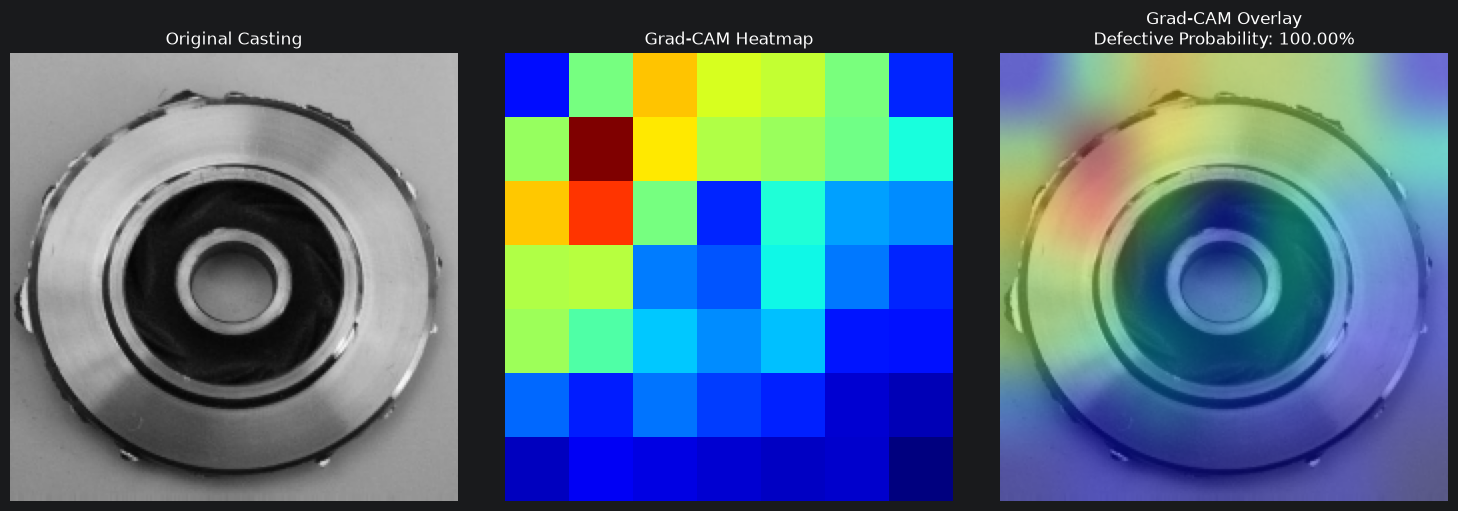

In [47]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_image.astype("uint8"))
plt.title("Original Casting")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(superimposed)
plt.title(
    f"Grad-CAM Overlay\n"
    f"Defective Probability: {prediction:.2%}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [49]:
false_negative_paths = []

for path, true_label in zip(test_paths, test_labels):

    if true_label != 1:
        continue

    img = load_image(path)

    img_tensor = tf.expand_dims(
        img,
        axis=0
    )

    probability = model.predict(
        img_tensor,
        verbose=0
    )[0][0]

    predicted_label = int(probability >= 0.5)

    if predicted_label == 0:
        false_negative_paths.append(
            (path, probability)
        )

print(
    "False negatives found:",
    len(false_negative_paths)
)

for path, probability in false_negative_paths:
    print(
        f"{path} → "
        f"Defective probability: {probability:.4f}"
    )

False negatives found: 5
..\data\casting_512x512\def_front\cast_def_0_3855.jpeg → Defective probability: 0.1951
..\data\casting_512x512\def_front\cast_def_0_571.jpeg → Defective probability: 0.0136
..\data\casting_512x512\def_front\cast_def_0_9474.jpeg → Defective probability: 0.3429
..\data\casting_512x512\def_front\cast_def_0_2690.jpeg → Defective probability: 0.0742
..\data\casting_512x512\def_front\cast_def_0_2483.jpeg → Defective probability: 0.1508


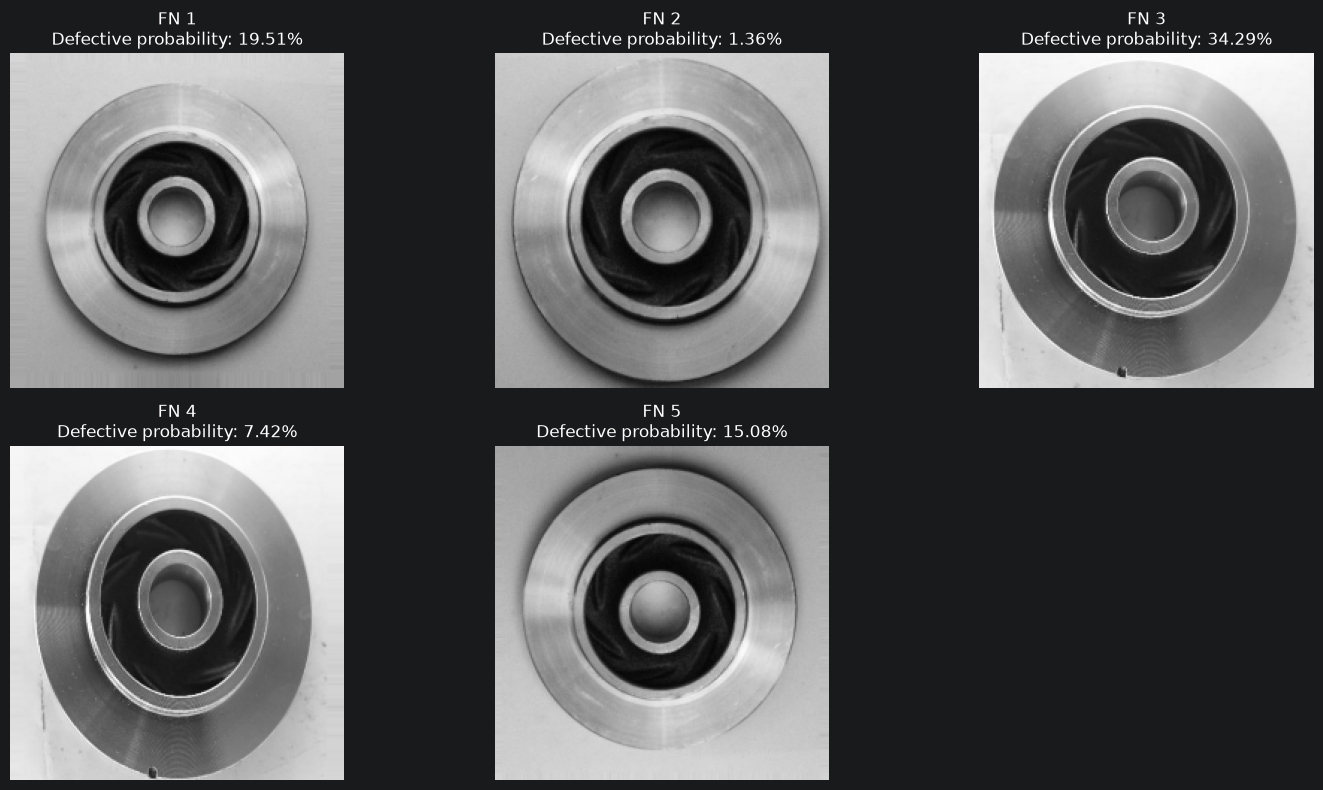

In [50]:
plt.figure(figsize=(15, 8))

for i, (path, probability) in enumerate(
    false_negative_paths
):

    img = load_image(path)

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        img.numpy().astype("uint8")
    )

    plt.title(
        f"FN {i + 1}\n"
        f"Defective probability: {probability:.2%}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [51]:
def get_gradcam_for_image(image_path):

    img = load_image(image_path)

    img_tensor = tf.expand_dims(
        img,
        axis=0
    )

    probability = model.predict(
        img_tensor,
        verbose=0
    )[0][0]

    heatmap = make_gradcam_heatmap(
        img_tensor,
        model,
        base_model,
        last_conv_layer
    )

    return (
        img,
        probability,
        heatmap
    )

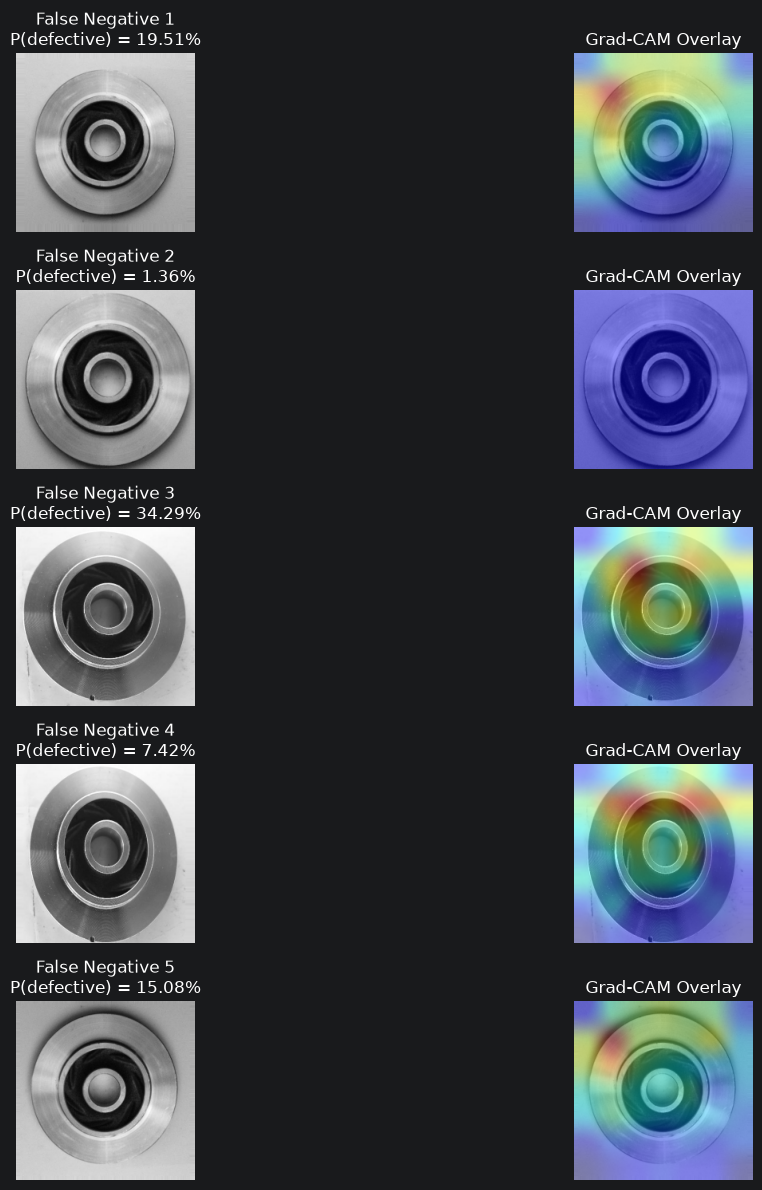

In [52]:
plt.figure(figsize=(15, 12))

for i, (path, _) in enumerate(
    false_negative_paths
):

    img, probability, heatmap = (
        get_gradcam_for_image(path)
    )

    heatmap_uint8 = np.uint8(
        255 * heatmap
    )

    jet = plt.colormaps["jet"]

    jet_colors = jet(
        np.arange(256)
    )[:, :3]

    jet_heatmap = jet_colors[
        heatmap_uint8
    ]

    jet_heatmap = tf.keras.utils.array_to_img(
        jet_heatmap
    )

    jet_heatmap = jet_heatmap.resize(
        (
            IMAGE_SIZE[1],
            IMAGE_SIZE[0]
        )
    )

    jet_heatmap = tf.keras.utils.img_to_array(
        jet_heatmap
    )

    original = img.numpy()

    overlay = (
        original * 0.6 +
        jet_heatmap * 0.4
    )

    overlay = np.clip(
        overlay,
        0,
        255
    ).astype("uint8")

    # Original
    plt.subplot(5, 2, 2 * i + 1)

    plt.imshow(
        original.astype("uint8")
    )

    plt.title(
        f"False Negative {i + 1}\n"
        f"P(defective) = {probability:.2%}"
    )

    plt.axis("off")

    # Grad-CAM
    plt.subplot(5, 2, 2 * i + 2)

    plt.imshow(overlay)

    plt.title(
        "Grad-CAM Overlay"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [53]:
test_records = []

for path, true_label in zip(test_paths, test_labels):

    img = load_image(path)

    img_tensor = tf.expand_dims(
        img,
        axis=0
    )

    probability = float(
        model.predict(
            img_tensor,
            verbose=0
        )[0][0]
    )

    predicted_label = int(
        probability >= 0.5
    )

    test_records.append({
        "path": path,
        "true_label": int(true_label),
        "probability": probability,
        "predicted_label": predicted_label
    })

print("Processed:", len(test_records))

Processed: 195


In [54]:
import pandas as pd

results_df = pd.DataFrame(
    test_records
)

results_df.head()

,path,true_label,probability,predicted_label
0,..\data\casting_512x512\def_front\cast_def_0_5...,1,1.000000,1
1,..\data\casting_512x512\def_front\cast_def_0_3...,1,1.000000,1
2,..\data\casting_512x512\def_front\cast_def_0_3...,1,0.999995,1
3,..\data\casting_512x512\ok_front\cast_ok_0_265...,0,0.006748,0
4,..\data\casting_512x512\def_front\cast_def_0_7...,1,0.998623,1


In [55]:
results_df["actual"] = results_df[
    "true_label"
].map({
    0: "Non-defective",
    1: "Defective"
})

results_df["predicted"] = results_df[
    "predicted_label"
].map({
    0: "Non-defective",
    1: "Defective"
})

results_df.head()

,path,true_label,probability,predicted_label,actual,predicted
0,..\data\casting_512x512\def_front\cast_def_0_5...,1,1.000000,1,Defective,Defective
1,..\data\casting_512x512\def_front\cast_def_0_3...,1,1.000000,1,Defective,Defective
2,..\data\casting_512x512\def_front\cast_def_0_3...,1,0.999995,1,Defective,Defective
3,..\data\casting_512x512\ok_front\cast_ok_0_265...,0,0.006748,0,Non-defective,Non-defective
4,..\data\casting_512x512\def_front\cast_def_0_7...,1,0.998623,1,Defective,Defective


In [56]:
errors_df = results_df[
    results_df["true_label"] !=
    results_df["predicted_label"]
]

print(
    "Total errors:",
    len(errors_df)
)

print(errors_df[
    [
        "actual",
        "predicted",
        "probability",
        "path"
    ]
])

Total errors: 5
        actual      predicted  probability  \
9    Defective  Non-defective     0.195118   
51   Defective  Non-defective     0.013625   
110  Defective  Non-defective     0.342876   
137  Defective  Non-defective     0.074214   
158  Defective  Non-defective     0.150758   

                                                  path  
9    ..\data\casting_512x512\def_front\cast_def_0_3...  
51   ..\data\casting_512x512\def_front\cast_def_0_5...  
110  ..\data\casting_512x512\def_front\cast_def_0_9...  
137  ..\data\casting_512x512\def_front\cast_def_0_2...  
158  ..\data\casting_512x512\def_front\cast_def_0_2...  


In [57]:
false_negatives = results_df[
    (results_df["true_label"] == 1) &
    (results_df["predicted_label"] == 0)
].copy()

false_negatives[
    [
        "probability",
        "path"
    ]
]

,probability,path
9,0.195118,..\data\casting_512x512\def_front\cast_def_0_3...
51,0.013625,..\data\casting_512x512\def_front\cast_def_0_5...
110,0.342876,..\data\casting_512x512\def_front\cast_def_0_9...
137,0.074214,..\data\casting_512x512\def_front\cast_def_0_2...
158,0.150758,..\data\casting_512x512\def_front\cast_def_0_2...


In [58]:
false_negatives.sort_values(
    "probability",
    ascending=False
)[
    [
        "probability",
        "path"
    ]
]

,probability,path
110,0.342876,..\data\casting_512x512\def_front\cast_def_0_9...
9,0.195118,..\data\casting_512x512\def_front\cast_def_0_3...
158,0.150758,..\data\casting_512x512\def_front\cast_def_0_2...
137,0.074214,..\data\casting_512x512\def_front\cast_def_0_2...
51,0.013625,..\data\casting_512x512\def_front\cast_def_0_5...


In [60]:
val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

In [62]:
def load_image(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [63]:
val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = (
    val_dataset
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [64]:
for images, labels in val_dataset.take(1):
    print("Images:", images.shape)
    print("Labels:", labels.shape)

Images: (32, 224, 224, 3)
Labels: (32,)


In [65]:
val_probabilities = model.predict(
    val_dataset
).flatten()

val_actual = np.concatenate([
    labels.numpy().flatten()
    for images, labels in val_dataset
]).astype(int)

print("Validation samples:", len(val_actual))

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step  
Validation samples: 195


In [66]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import numpy as np

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        val_actual,
        predictions
    ).ravel()

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "accuracy": accuracy_score(
            val_actual,
            predictions
        ),
        "precision": precision_score(
            val_actual,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            val_actual,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            val_actual,
            predictions,
            zero_division=0
        ),
        "FP": fp,
        "FN": fn
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,threshold,accuracy,precision,recall,f1,FP,FN
0,0.10,0.994872,1.0,0.991453,0.995708,0,1
1,0.15,0.994872,1.0,0.991453,0.995708,0,1
2,0.20,0.994872,1.0,0.991453,0.995708,0,1
3,0.25,0.994872,1.0,0.991453,0.995708,0,1
4,0.30,0.994872,1.0,0.991453,0.995708,0,1
5,0.35,0.994872,1.0,0.991453,0.995708,0,1
6,0.40,0.994872,1.0,0.991453,0.995708,0,1
7,0.45,0.994872,1.0,0.991453,0.995708,0,1
8,0.50,0.994872,1.0,0.991453,0.995708,0,1
9,0.55,0.994872,1.0,0.991453,0.995708,0,1


In [67]:
eligible = threshold_df[
    threshold_df["recall"] >= 0.95
]

best_threshold_row = eligible.loc[
    eligible["f1"].idxmax()
]

print("Best threshold meeting recall >= 95%:")
print(best_threshold_row)

Best threshold meeting recall >= 95%:
threshold    0.100000
accuracy     0.994872
precision    1.000000
recall       0.991453
f1           0.995708
FP           0.000000
FN           1.000000
Name: 0, dtype: float64


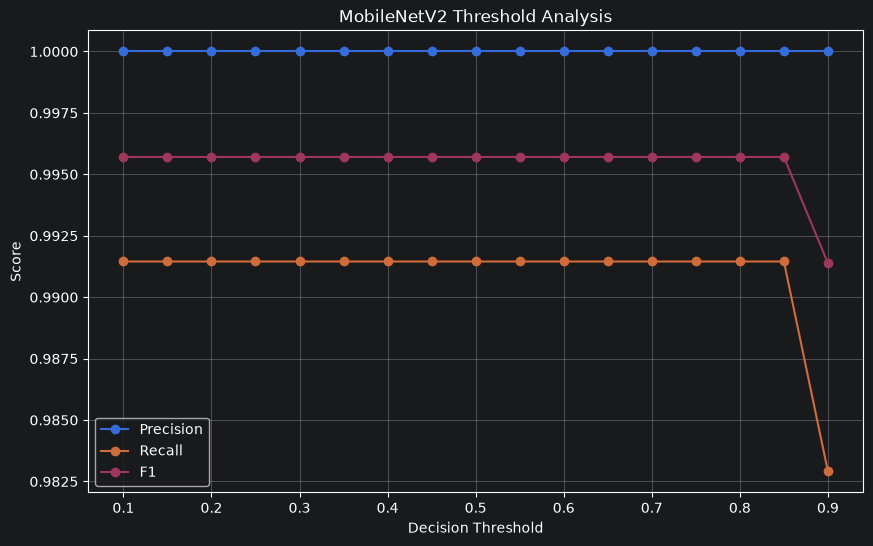

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("MobileNetV2 Threshold Analysis")
plt.legend()
plt.grid(True)

plt.show()

In [69]:
best_threshold = float(
    best_threshold_row["threshold"]
)

print("Selected threshold:", best_threshold)

Selected threshold: 0.1


In [72]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = (
    test_dataset
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [73]:
for images, labels in test_dataset.take(1):
    print("Images:", images.shape)
    print("Labels:", labels.shape)

Images: (32, 224, 224, 3)
Labels: (32,)


In [74]:
test_probabilities = model.predict(
    test_dataset
).flatten()

print("Test predictions:", len(test_probabilities))

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step
Test predictions: 195


In [75]:
test_actual = np.array(
    test_labels
).astype(int)

print("Test labels:", len(test_actual))

Test labels: 195


In [76]:
eligible = threshold_df[
    threshold_df["recall"] >= 0.95
].copy()

eligible = eligible.sort_values(
    ["FP", "FN", "f1"],
    ascending=[True, True, False]
)

print(eligible.to_string(index=False))

 threshold  accuracy  precision   recall       f1  FP  FN
      0.10  0.994872        1.0 0.991453 0.995708   0   1
      0.15  0.994872        1.0 0.991453 0.995708   0   1
      0.20  0.994872        1.0 0.991453 0.995708   0   1
      0.25  0.994872        1.0 0.991453 0.995708   0   1
      0.30  0.994872        1.0 0.991453 0.995708   0   1
      0.35  0.994872        1.0 0.991453 0.995708   0   1
      0.40  0.994872        1.0 0.991453 0.995708   0   1
      0.45  0.994872        1.0 0.991453 0.995708   0   1
      0.50  0.994872        1.0 0.991453 0.995708   0   1
      0.55  0.994872        1.0 0.991453 0.995708   0   1
      0.60  0.994872        1.0 0.991453 0.995708   0   1
      0.65  0.994872        1.0 0.991453 0.995708   0   1
      0.70  0.994872        1.0 0.991453 0.995708   0   1
      0.75  0.994872        1.0 0.991453 0.995708   0   1
      0.80  0.994872        1.0 0.991453 0.995708   0   1
      0.85  0.994872        1.0 0.991453 0.995708   0   1
      0.90  0.

In [77]:
best_threshold_row = eligible.iloc[0]

best_threshold = float(
    best_threshold_row["threshold"]
)

print("Locked threshold:", best_threshold)

Locked threshold: 0.1


In [78]:
test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

In [79]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(
    test_actual,
    test_predictions
)

precision = precision_score(
    test_actual,
    test_predictions,
    zero_division=0
)

recall = recall_score(
    test_actual,
    test_predictions,
    zero_division=0
)

f1 = f1_score(
    test_actual,
    test_predictions,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    test_actual,
    test_predictions
).ravel()

print("========== FINAL TEST RESULTS ==========")
print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nConfusion Matrix:")
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

========== FINAL TEST RESULTS ==========
Threshold : 0.10
Accuracy  : 0.9846
Precision : 0.9914
Recall    : 0.9829
F1 Score  : 0.9871

Confusion Matrix:
TN: 77
FP: 1
FN: 2
TP: 115


In [80]:
print("========== FINAL MODEL ==========")
print("Model: Fine-tuned MobileNetV2")
print(f"Decision threshold: {best_threshold:.2f}")

print("\n========== TEST PERFORMANCE ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\n========== CONFUSION MATRIX ==========")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

========== FINAL MODEL ==========
Model: Fine-tuned MobileNetV2
Decision threshold: 0.10

========== TEST PERFORMANCE ==========
Accuracy : 0.9846
Precision: 0.9914
Recall   : 0.9829
F1 Score : 0.9871

========== CONFUSION MATRIX ==========
True Negatives : 77
False Positives: 1
False Negatives: 2
True Positives : 115


In [81]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        tn,
        fp,
        fn,
        tp
    ]
})

final_results

,Metric,Value
0,Accuracy,0.984615
1,Precision,0.991379
2,Recall,0.982906
3,F1 Score,0.987124
4,True Negatives,77.000000
5,False Positives,1.000000
6,False Negatives,2.000000
7,True Positives,115.000000
